Raw Data Conversion to Clean Data

In [1]:
import pandas as pd

In [2]:
pd.__version__

'3.0.3'

In [3]:
emp=pd.read_excel(r"F:\download\Rawdata.xlsx")

In [4]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year
5,Kim,NLP,55yr,Delhi,6000^$0,10+


In [5]:
id(emp)

2001767444368

In [6]:
emp.columns

Index(['Name', 'Domain', 'Age', 'Location', 'Salary', 'Exp'], dtype='str')

In [7]:
emp.shape

(6, 6)

In [8]:
emp.head()

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year


In [9]:
emp.tail()

,Name,Domain,Age,Location,Salary,Exp
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year
5,Kim,NLP,55yr,Delhi,6000^$0,10+


In [10]:
emp.info()# here total is 6 attributes and if 4 - non null values out of 6 and null values out of 6

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       4 non-null      str  
 3   Location  4 non-null      str  
 4   Salary    6 non-null      str  
 5   Exp       5 non-null      str  
dtypes: str(6)
memory usage: 619.0 bytes


In [11]:
emp.isnull()

,Name,Domain,Age,Location,Salary,Exp
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,False,False,True,False,False,True
4,False,False,False,True,False,False
5,False,False,False,False,False,False


In [12]:
emp.isnull().sum()#if null values is there then it caluclates and gvie it

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

In [13]:
emp.dtypes

Name        str
Domain      str
Age         str
Location    str
Salary      str
Exp         str
dtype: object

data cleaning

cleaning the data

In [14]:
emp['Name'] # this all fail in deployment

0      Mike
1    Teddy^
2     Uma#r
3      Jane
4    Uttam*
5       Kim
Name: Name, dtype: str

In [15]:
emp['Name'].tolist()

['Mike', 'Teddy^', 'Uma#r', 'Jane', 'Uttam*', 'Kim']

In [16]:
emp['Name'] = emp['Name'].str.replace(r'\W', '', regex=True)

In [17]:
emp['Name']

0     Mike
1    Teddy
2     Umar
3     Jane
4    Uttam
5      Kim
Name: Name, dtype: str

In [18]:
emp['Domain']=emp['Domain'].str.replace(r'\W','',regex=True)

In [19]:
emp['Domain']

0    Datascience
1        Testing
2    Dataanalyst
3      Analytics
4     Statistics
5            NLP
Name: Domain, dtype: str

In [20]:
emp['Age']=emp['Age'].str.replace(r'\W','',regex=True)

In [21]:
emp['Age']

0    34years
1       45yr
2        NaN
3        NaN
4       67yr
5       55yr
Name: Age, dtype: str

In [22]:
emp['Age']=emp['Age'].str.extract('(\d+)')#d+ means extract the digit

In [23]:
emp['Age']

0     34
1     45
2    NaN
3    NaN
4     67
5     55
Name: Age, dtype: str

In [24]:
emp['Location']=emp['Location'].str.replace(r'\W','',regex=True)

In [25]:
emp['Location']

0       Mumbai
1    Bangalore
2          NaN
3     Hyderbad
4          NaN
5        Delhi
Name: Location, dtype: str

In [26]:
emp['Salary']=emp['Salary'].str.replace(r'\W','',regex=True)

In [27]:
emp['Salary']

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: str

In [28]:
emp.head()

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2+
1,Teddy,Testing,45,Bangalore,10000,<3
2,Umar,Dataanalyst,NaN,NaN,15000,4> yrs
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5+ year


In [29]:
emp['Exp']=emp['Exp'].str.extract('(\d+)')

In [30]:
emp['Exp']

0      2
1      3
2      4
3    NaN
4      5
5     10
Name: Exp, dtype: str

Now Apply the Eda Technique

In [31]:
clean_data=emp.copy()

In [32]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


Eda Techinqu

In [35]:
clean_data['Exp'] = clean_data['Exp'].fillna(
    np.mean(pd.to_numeric(clean_data['Exp']))
)

In [36]:
clean_data['Exp']

0      2
1      3
2      4
3    4.8
4      5
5     10
Name: Exp, dtype: object

In [37]:
clean_data['Age']


0     34
1     45
2    NaN
3    NaN
4     67
5     55
Name: Age, dtype: str

In [38]:
import numpy as np

In [39]:
clean_data['Age']=clean_data['Age'].fillna(np.mean(pd.to_numeric(clean_data['Age'])))#converting tthe missing values into the 


In [40]:
clean_data['Age']

0       34
1       45
2    50.25
3    50.25
4       67
5       55
Name: Age, dtype: object

In [41]:
clean_data['Location']

0       Mumbai
1    Bangalore
2          NaN
3     Hyderbad
4          NaN
5        Delhi
Name: Location, dtype: str

In [42]:
clean_data['Location']=clean_data['Location'].fillna(clean_data['Location'].mode()[0])


In [43]:
clean_data['Location']

0       Mumbai
1    Bangalore
2    Bangalore
3     Hyderbad
4    Bangalore
5        Delhi
Name: Location, dtype: str

In [44]:
clean_data['Exp'].isna()

0    False
1    False
2    False
3    False
4    False
5    False
Name: Exp, dtype: bool

In [45]:
clean_data['Exp']

0      2
1      3
2      4
3    4.8
4      5
5     10
Name: Exp, dtype: object

In [46]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,Bangalore,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,4.8
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [47]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      str   
 1   Domain    6 non-null      str   
 2   Age       6 non-null      object
 3   Location  6 non-null      str   
 4   Salary    6 non-null      str   
 5   Exp       6 non-null      object
dtypes: object(2), str(4)
memory usage: 574.0+ bytes


In [48]:
clean_data['Age']=clean_data['Age'].astype(int)

In [49]:
clean_data['Age']

0    34
1    45
2    50
3    50
4    67
5    55
Name: Age, dtype: int64

In [50]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      str   
 1   Domain    6 non-null      str   
 2   Age       6 non-null      int64 
 3   Location  6 non-null      str   
 4   Salary    6 non-null      str   
 5   Exp       6 non-null      object
dtypes: int64(1), object(1), str(4)
memory usage: 574.0+ bytes


In [51]:
clean_data['Age']=clean_data['Age'].astype(int)


In [52]:
clean_data['Salary']=clean_data['Salary'].astype(int)

In [53]:
clean_data['Exp']=clean_data['Exp'].astype(int)

In [54]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       6 non-null      int64
 3   Location  6 non-null      str  
 4   Salary    6 non-null      int64
 5   Exp       6 non-null      int64
dtypes: int64(3), str(3)
memory usage: 544.0 bytes


In [55]:
clean_data['Name']=clean_data['Name'].astype('category')
clean_data['Domain']=clean_data['Domain'].astype('category')
clean_data['Location']=clean_data['Location'].astype('category')



In [56]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Name      6 non-null      category
 1   Domain    6 non-null      category
 2   Age       6 non-null      int64   
 3   Location  6 non-null      category
 4   Salary    6 non-null      int64   
 5   Exp       6 non-null      int64   
dtypes: category(3), int64(3)
memory usage: 529.0 bytes


In [57]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [58]:
clean_data.to_csv('clean_data.csv')

In [59]:
import os
os.getcwd()

'C:\\Users\\SKY TECH'

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
import warnings
warnings.filterwarnings

<function _py_warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [63]:
clean_data['Salary']

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

C:\Users\SKY TECH\AppData\Local\Temp\ipykernel_15312\1786024508.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  vis1=sns.distplot(clean_data['Salary'])


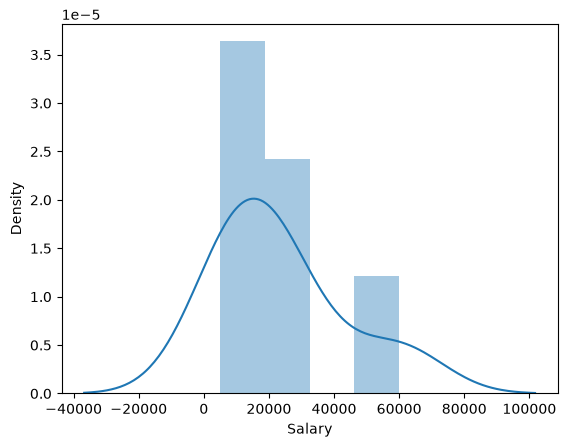

In [65]:
vis1=sns.distplot(clean_data['Salary'])#here we did not get the outlier so

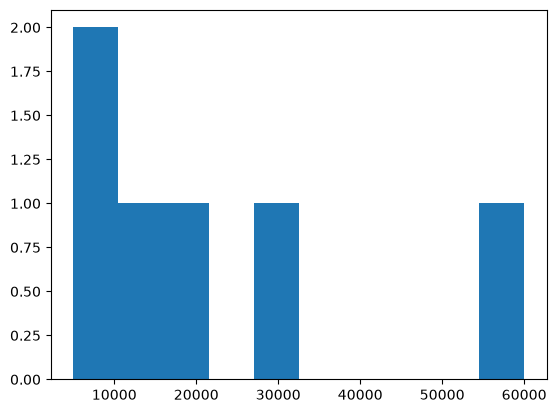

In [66]:
vis2=plt.hist(clean_data['Salary'])#here we we get the outlier

In [67]:
 clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


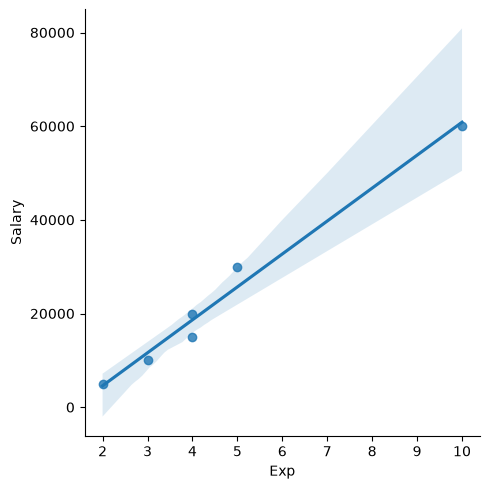

In [68]:
vis4=sns.lmplot(clean_data,x='Exp',y='Salary')#positive corelation both are going forward

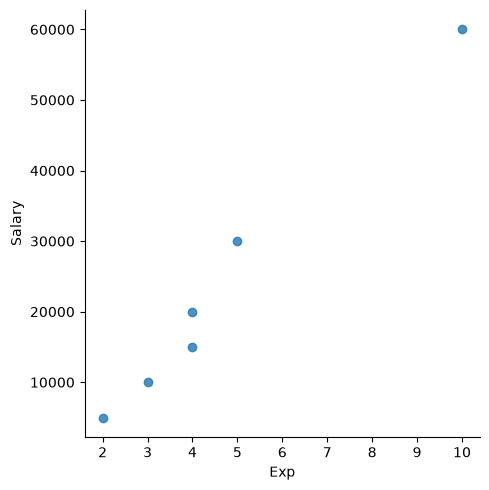

In [69]:
vis5=sns.lmplot(clean_data,x='Exp',y='Salary',fit_reg=False)#bivariate analysis

In [70]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [71]:
X_iv=clean_data[['Name','Domain','Age','Location','Exp']]#variable identifcation

In [73]:
X_iv#independento variable

,Name,Domain,Age,Location,Exp
0,Mike,Datascience,34,Mumbai,2
1,Teddy,Testing,45,Bangalore,3
2,Umar,Dataanalyst,50,Bangalore,4
3,Jane,Analytics,50,Hyderbad,4
4,Uttam,Statistics,67,Bangalore,5
5,Kim,NLP,55,Delhi,10


In [76]:
x_dv=clean_data['Salary']

In [80]:
print(x_dv)


0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64


In [82]:
clean_data#if we apply the a ml algorithm then algorithm doesnt understand the what is mike what location ,name so

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [81]:
emp#if we apply the a ml algorithm then algorithm doesnt understand the what is mike what location ,name so

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [83]:
imputation=pd.get_dummies(clean_data,dtype=int)

In [84]:
imputation#transformer .means changigng it categorical date into numerical values

,Age,Salary,Exp,Name_Jane,Name_Kim,Name_Mike,Name_Teddy,Name_Umar,Name_Uttam,Domain_Analytics,Domain_Dataanalyst,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Bangalore,Location_Delhi,Location_Hyderbad,Location_Mumbai
0,34,5000,2,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
1,45,10000,3,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0
2,50,15000,4,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0
3,50,20000,4,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,67,30000,5,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0
5,55,60000,10,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [85]:
len(clean_data) 

6

raw data with lot of regex unclear data
fill missing numerical & categorical
clean_data(data cleaning) 3 months
outlier treatment,univariat,bivariant
split the data into x_iv and x_dv
impute categorical data to numerical
eda part complete